In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

dir_data = Path("tiles/data/tiles-v3-so2-p99-2021-2024")

print("Cargando dataset unificado v2...")
df = pd.read_parquet(dir_data / "tiles_meta.parquet")

with np.load(dir_data / "tiles_train.npz") as data:
    images = data["data"]
    bands = list(data["bands"])

print(f"Metadata: {df.shape}")
print(f"Imágenes: {images.shape}")
print(f"Bandas disponibles: {bands}")

Cargando dataset unificado v2...
Metadata: (1150, 24)
Imágenes: (1150, 13, 64, 64)
Bandas disponibles: [np.str_('B1'), np.str_('B2'), np.str_('B3'), np.str_('B4'), np.str_('B5'), np.str_('B6'), np.str_('B7'), np.str_('B8'), np.str_('B8A'), np.str_('B9'), np.str_('B11'), np.str_('B12'), np.str_('SCL')]


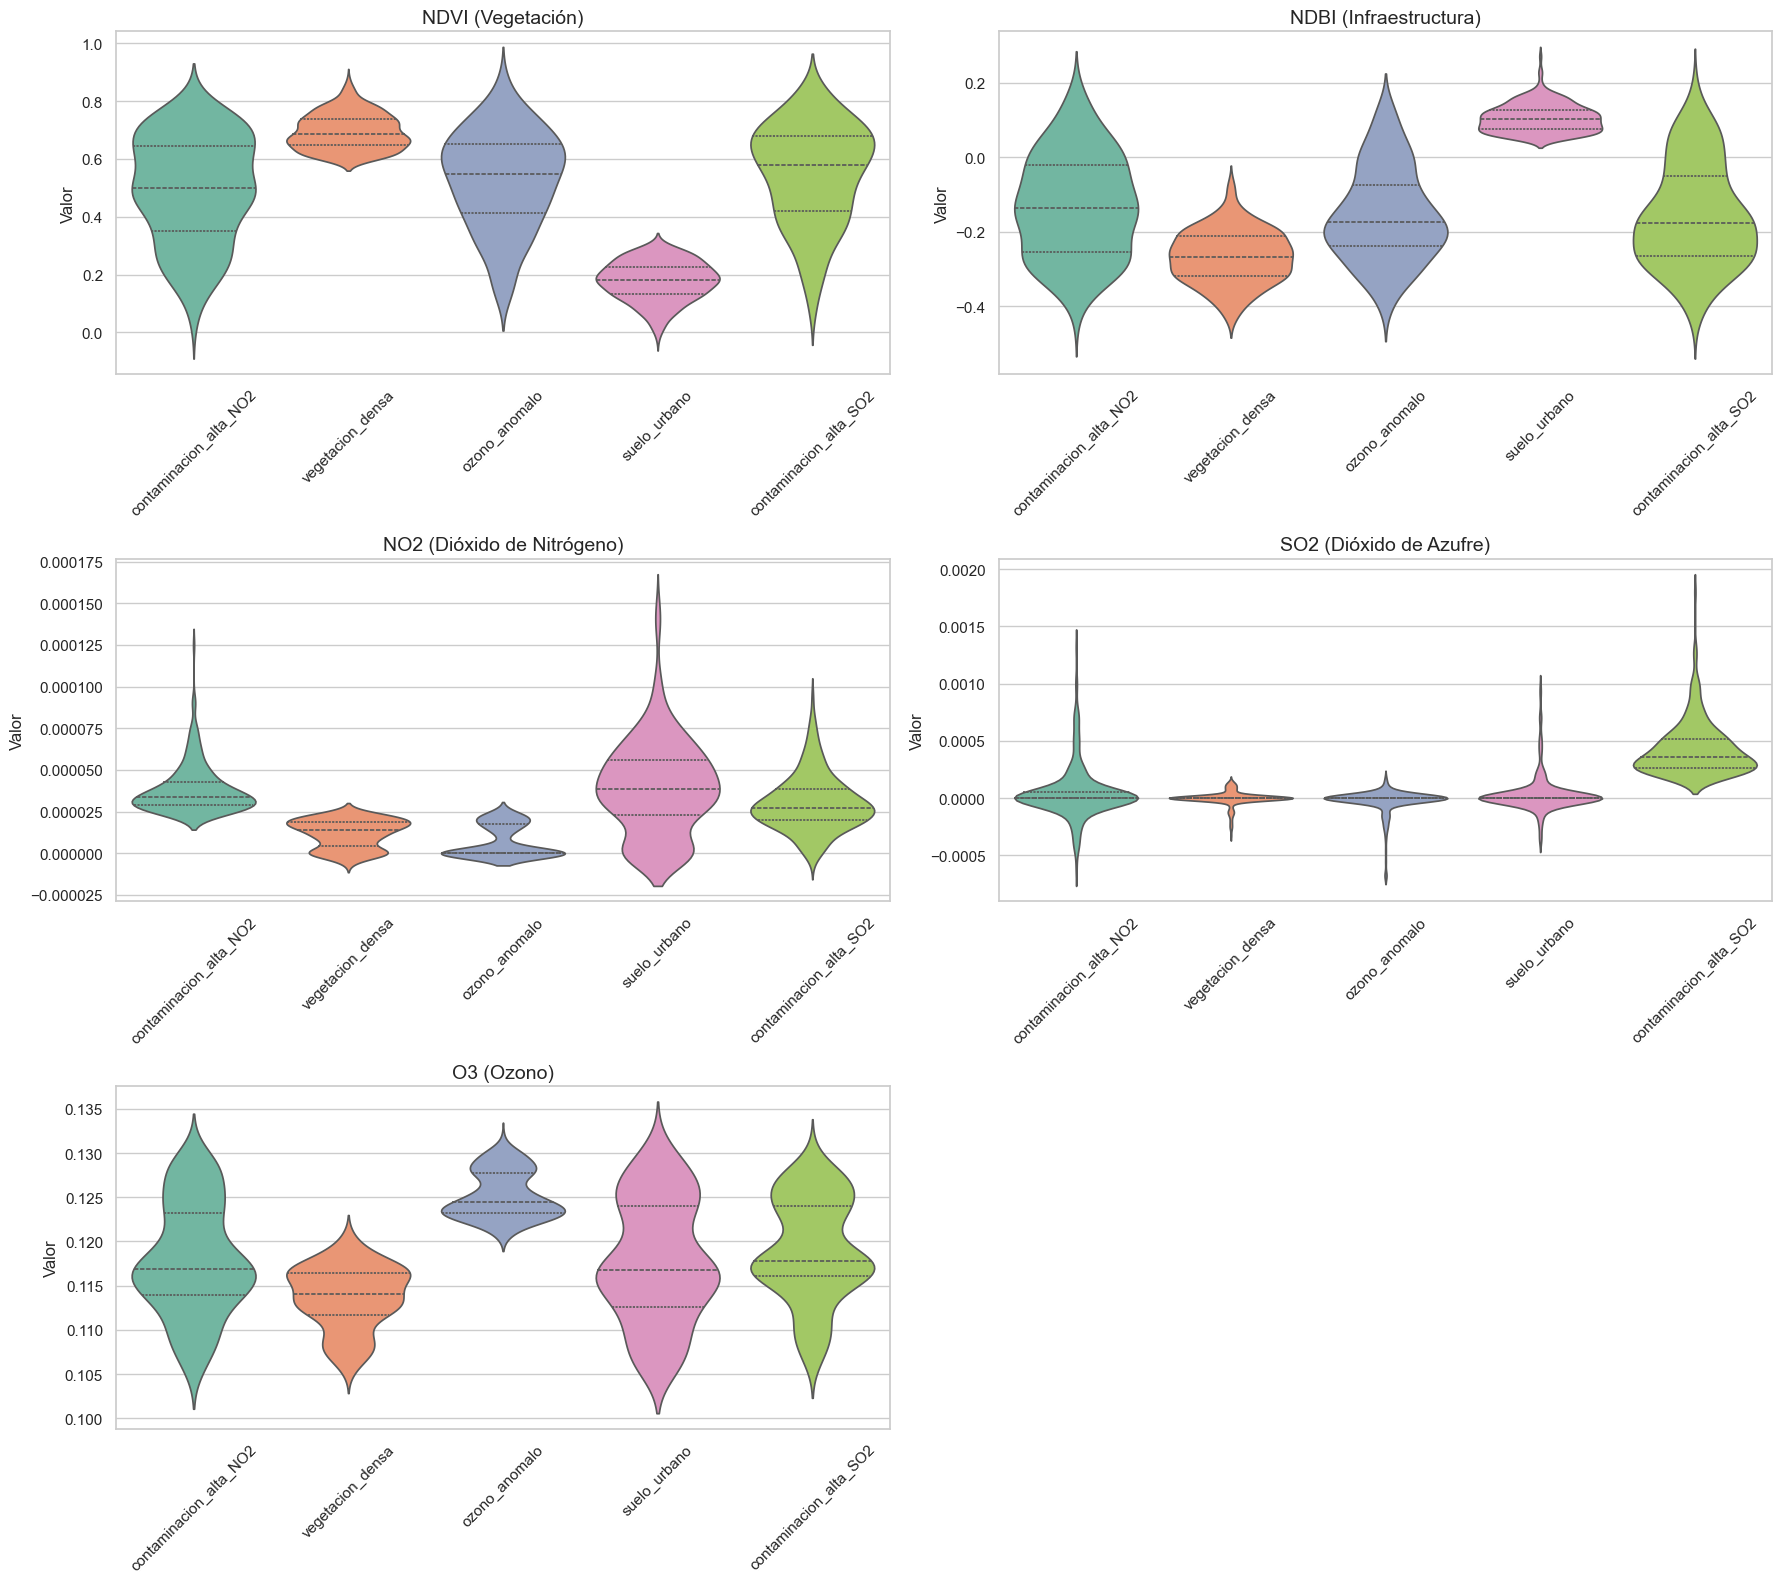

In [2]:
vars_to_plot = ["ndvi", "ndbi", "no2", "so2", "o3"]
titulos = ["NDVI (Vegetación)", "NDBI (Infraestructura)", "NO2 (Dióxido de Nitrógeno)", "SO2 (Dióxido de Azufre)", "O3 (Ozono)"]

fig, axes = plt.subplots(3, 2, figsize=(18, 16))
axes = axes.flatten()

palette = sns.color_palette("Set2", n_colors=5)

for i, (var, titulo) in enumerate(zip(vars_to_plot, titulos)):
    sns.violinplot(
        data=df, 
        x="clase", 
        y=var,
        hue="clase",
        ax=axes[i], 
        palette=palette,
        inner="quartile",
        density_norm="width"
    )
    axes[i].set_title(titulo, fontsize=14)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Valor")

axes[-1].axis('off')
plt.tight_layout()
plt.show()

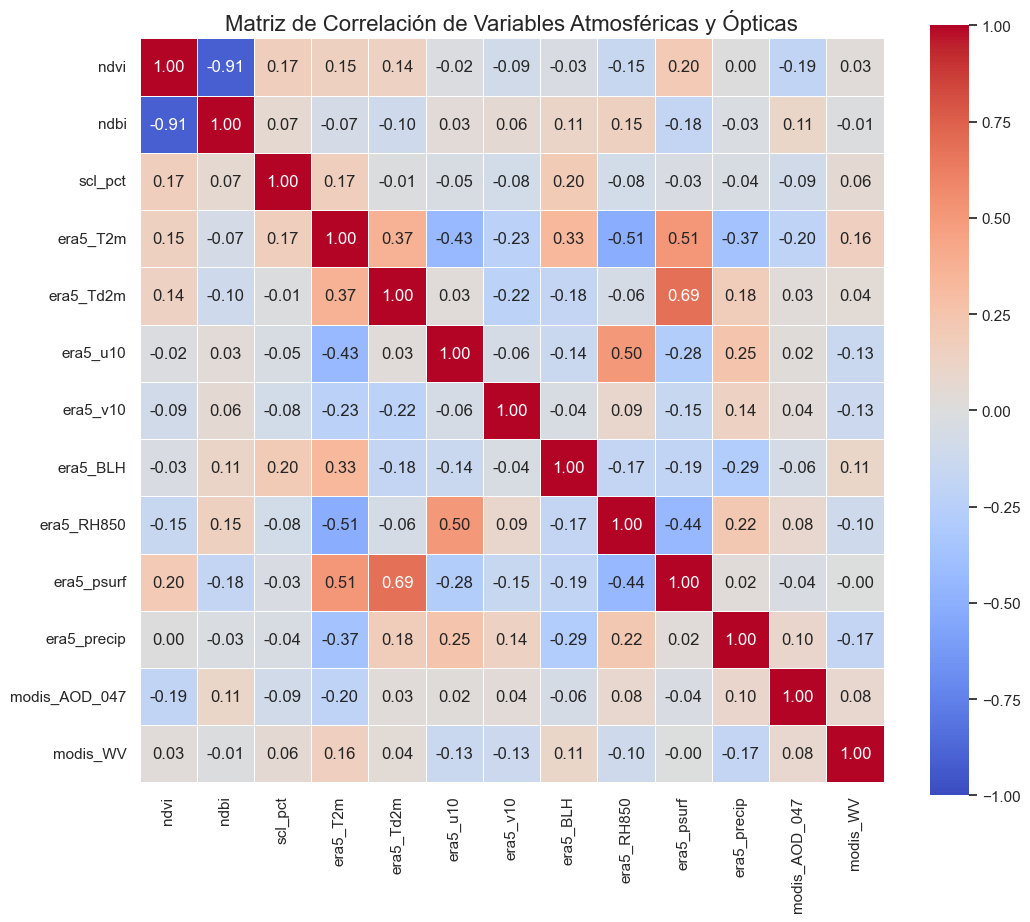

In [3]:
cols_numericas = [
    "ndvi", "ndbi", "scl_pct", "era5_T2m", "era5_Td2m", 
    "era5_u10", "era5_v10", "era5_BLH", "era5_RH850", 
    "era5_psurf", "era5_precip", "modis_AOD_047", "modis_WV"
]

df_corr = df[cols_numericas].fillna(df[cols_numericas].median())

corr_matrix = df_corr.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    square=True,
    linewidths=0.5
)
plt.title("Matriz de Correlación de Variables Atmosféricas y Ópticas", fontsize=16)
plt.show()

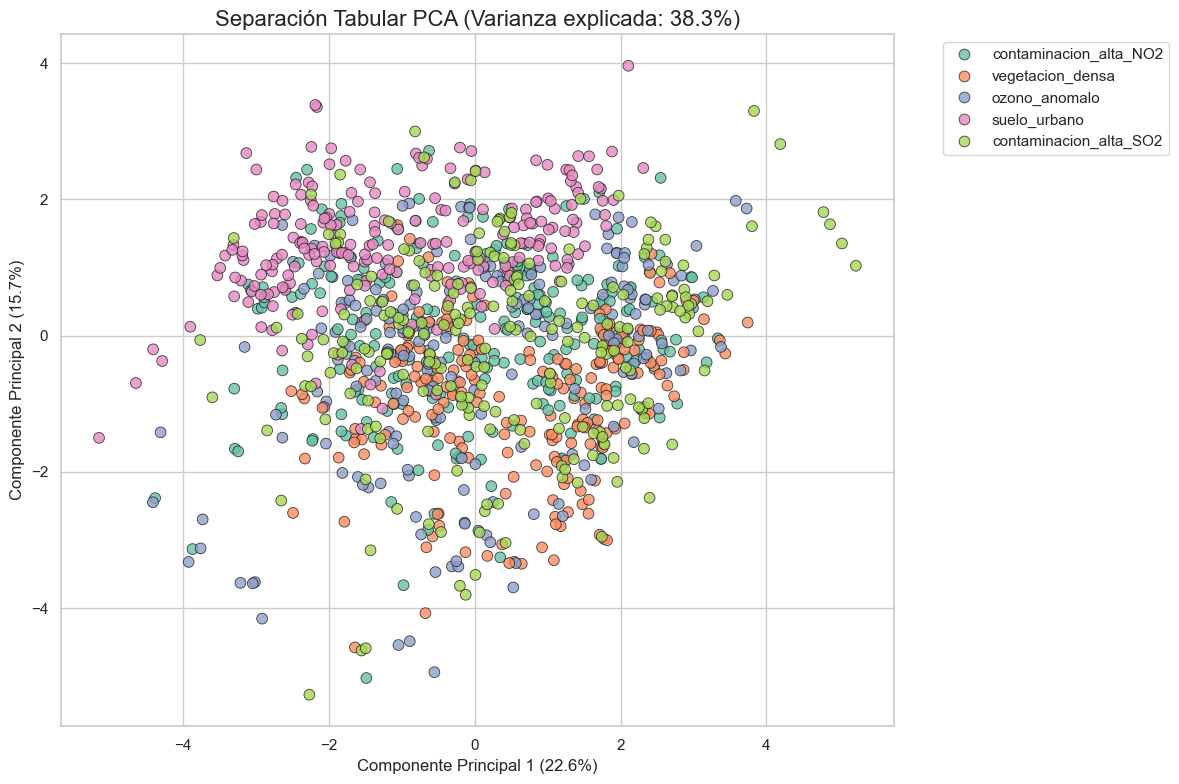

In [4]:
# Escalamos los datos tabulares antes del PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_corr)

pca = PCA(n_components=2)
componentes_pca = pca.fit_transform(X_scaled)

df["PCA1"] = componentes_pca[:, 0]
df["PCA2"] = componentes_pca[:, 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df, 
    x="PCA1", 
    y="PCA2", 
    hue="clase", 
    palette="Set2", 
    s=60, 
    alpha=0.8,
    edgecolor="k"
)
plt.title(f"Separación Tabular PCA (Varianza explicada: {pca.explained_variance_ratio_.sum()*100:.1f}%)", fontsize=16)
plt.xlabel(f"Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

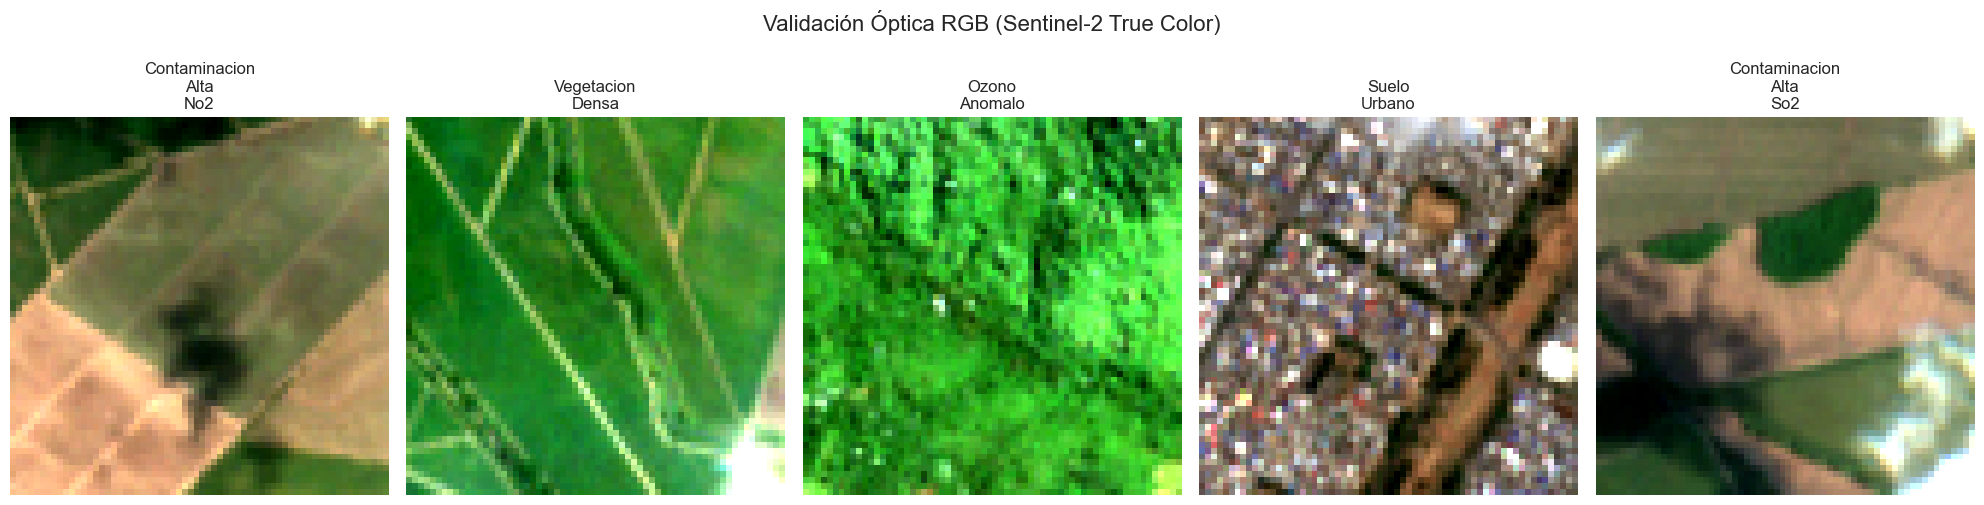

In [5]:
idx_b4 = bands.index("B4")
idx_b3 = bands.index("B3")
idx_b2 = bands.index("B2")

clases_unicas = df["clase"].unique()

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, clase in enumerate(clases_unicas):
    idx_muestra = df[df["clase"] == clase].sample(1, random_state=42).index[0]
    tile_rgb = images[idx_muestra, [idx_b4, idx_b3, idx_b2], :, :]
    
    tile_rgb = np.transpose(tile_rgb, (1, 2, 0))
    
    p2, p98 = np.percentile(tile_rgb, (2, 98))
    tile_rgb_norm = np.clip((tile_rgb - p2) / (p98 - p2 + 1e-6), 0, 1)
    
    axes[i].imshow(tile_rgb_norm)
    axes[i].set_title(clase.replace("_", "\n").title(), fontsize=12)
    axes[i].axis('off')

plt.suptitle("Validación Óptica RGB (Sentinel-2 True Color)", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()